# Load and Preview the Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load the dataset
df = pd.read_csv('high-school-directory.csv')

# Preview initial data
print(df.head())

      dbn                                        school_name    borough  \
0  27Q260          Frederick Douglass Academy VI High School     Queens   
1  21K559        Life Academy High School for Film and Music   Brooklyn   
2  16K393     Frederick Douglass Academy IV Secondary School   Brooklyn   
3  08X305                               Pablo Neruda Academy      Bronx   
4  03M485  Fiorello H. LaGuardia High School of Music & A...  Manhattan   

  building_code  phone_number    fax_number  grade_span_min  grade_span_max  \
0          Q465  718-471-2154  718-471-2890             9.0              12   
1          K400  718-333-7750  718-333-7775             9.0              12   
2          K026  718-574-2820  718-574-2821             9.0              12   
3          X450  718-824-1682  718-824-1663             9.0              12   
4          M485  212-496-0700  212-724-5748             9.0              12   

   expgrade_span_min  expgrade_span_max  ... Council District Census Tract

# Clean Column Names

In [3]:
# Function to clean column names: lowercase, replace spaces, remove special characters
def clean_column_name(col):
    col = col.lower()
    col = col.replace(' ', '_')
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

df.columns = [clean_column_name(c) for c in df.columns]

# Verify cleaned columns
print(df.columns)

Index(['dbn', 'school_name', 'borough', 'building_code', 'phone_number',
       'fax_number', 'grade_span_min', 'grade_span_max', 'expgrade_span_min',
       'expgrade_span_max', 'bus', 'subway', 'primary_address_line_1', 'city',
       'state_code', 'postcode', 'website', 'total_students', 'campus_name',
       'school_type', 'overview_paragraph', 'program_highlights',
       'language_classes', 'advancedplacement_courses', 'online_ap_courses',
       'online_language_courses', 'extracurricular_activities',
       'psal_sports_boys', 'psal_sports_girls', 'psal_sports_coed',
       'school_sports', 'partner_cbo', 'partner_hospital', 'partner_highered',
       'partner_cultural', 'partner_nonprofit', 'partner_corporate',
       'partner_financial', 'partner_other', 'addtl_info1', 'addtl_info2',
       'start_time', 'end_time', 'se_services', 'ell_programs',
       'school_accessibility_description', 'number_programs', 'priority01',
       'priority02', 'priority03', 'priority04', 'prior

# Filtering for Brooklyn

In [4]:
# Filter for Brooklyn schools
brooklyn_df = df[df['borough'].str.strip() == 'Brooklyn']

# Total Unique Schools in Brooklyn

In [5]:
total_bk_unique = brooklyn_df['dbn'].nunique()
print(f"Total Unique Schools in Brooklyn: {total_bk_unique}")

Total Unique Schools in Brooklyn: 121


# Grade 9 Entry in Brooklyn

In [6]:
# Check range: min_grade <= 9 AND max_grade >= 9
gr9_entry_bk = brooklyn_df[(brooklyn_df['grade_span_min'] <= 9) &
                           (brooklyn_df['grade_span_max'] >= 9)]

print(f"Schools in Brooklyn offering Grade 9 entry: {gr9_entry_bk['dbn'].nunique()}")

Schools in Brooklyn offering Grade 9 entry: 121


# Grouping and Summarizing

In [7]:
# Count of unique schools per borough
schools_per_boro = df.groupby('borough')['dbn'].nunique().sort_values(ascending=False)

# Average number of students per borough
avg_students_boro = df.groupby('borough')['total_students'].mean().sort_values(ascending=False)

# Summary statistics for grade_span_max by borough
grade_stats = df.groupby('borough')['grade_span_max'].describe()

print("Schools per Borough:\n", schools_per_boro)
print("\nAverage Students per Borough:\n", avg_students_boro)
print("\nGrade Span Max Summary:\n", grade_stats)

Schools per Borough:
 borough
Brooklyn         121
Bronx            118
Manhattan        106
Queens            80
Staten Island     10
Name: dbn, dtype: int64

Average Students per Borough:
 borough
Staten Island    1847.500000
Queens           1046.644737
Brooklyn          699.134454
Manhattan         589.825243
Bronx             490.406780
Name: total_students, dtype: float64

Grade Span Max Summary:
                count       mean       std   min   25%   50%   75%   max
borough                                                                
Bronx          118.0  11.906780  0.369506   9.0  12.0  12.0  12.0  12.0
Brooklyn       121.0  11.933884  0.381566   9.0  12.0  12.0  12.0  12.0
Manhattan      106.0  11.877358  0.472135   9.0  12.0  12.0  12.0  12.0
Queens          80.0  11.825000  0.497462  10.0  12.0  12.0  12.0  12.0
Staten Island   10.0  12.000000  0.000000  12.0  12.0  12.0  12.0  12.0


# Visualizations

**Bar Chart: Number of Schools per Borough**

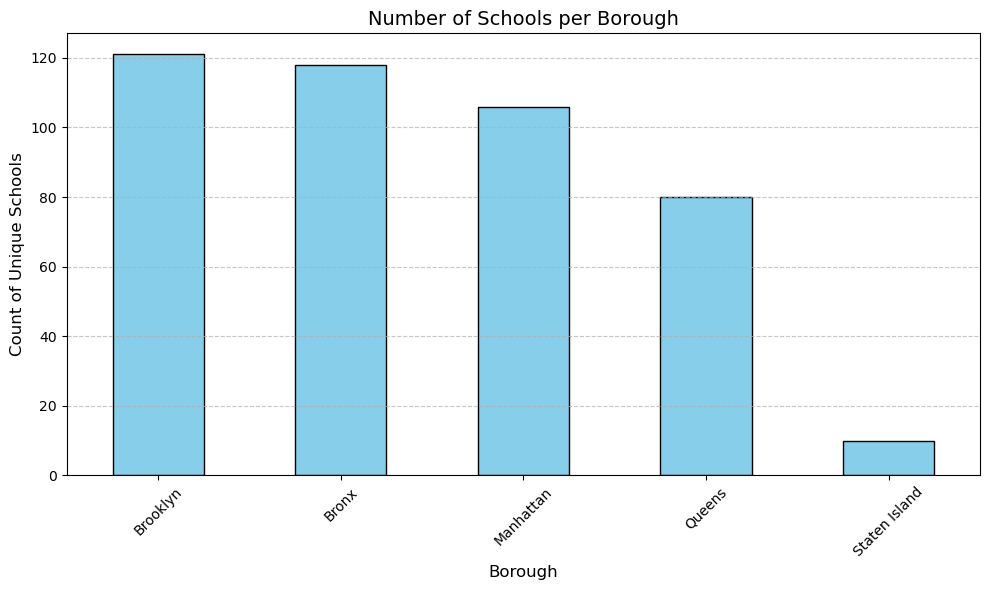

In [8]:
plt.figure(figsize=(10, 6))
schools_per_boro.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Schools per Borough', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Count of Unique Schools', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Key Insights & Observations
**School Count vs. Student Density:** While Brooklyn and the Bronx have the highest number of schools (121 and 118 respectively), Staten Island has the largest schools on average. Staten Island schools average 1,847 students, which is nearly triple the average school size in the Bronx (~490 students). This suggests that while other boroughs favor many smaller, specialized schools, Staten Island relies on a few large, high-capacity campuses.

**The "High School" Standard:** The grade_span_max summary reveals high consistency across the city. The median (50%) and 75th percentile for all boroughs is Grade 12, indicating that nearly all institutions in this directory are full four-year high schools or 6-12 secondary schools.

**Brooklyn’s Reach:** Brooklyn leads the city in school variety, offering 121 unique DBNs. Every single one of these schools includes Grade 9 in its span, making it the borough with the most diverse geographic options for incoming freshmen.